Loading the datset

In [ ]:
import pandas as pd
data = pd.read_csv("/content/Crop_recommendation.csv")

In [ ]:
print("Dataset Shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())

Dataset Shape: (2200, 8)

First 5 rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [ ]:
print("\nDataset Info:")
print(data.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None


In [ ]:
print("\nStatistical Summary:")
print(data.describe())


Statistical Summary:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.935091   298.560117  


DEFINE FEATURES Soil features (modal 1) & Weather features (modal 2)

In [ ]:
soil_features = ['ph']
weather_features = ['temperature', 'humidity', 'rainfall']

# Inputs
X_soil = data[soil_features]
X_weather = data[weather_features]

# Target (predict N, P, K - regression)
y = data[['N', 'P', 'K']]

In [ ]:
print("\nSoil Features Sample:")
print(X_soil.head())

print("\nWeather Features Sample:")
print(X_weather.head())


Soil Features Sample:
         ph
0  6.502985
1  7.038096
2  7.840207
3  6.980401
4  7.628473

Weather Features Sample:
   temperature   humidity    rainfall
0    20.879744  82.002744  202.935536
1    21.770462  80.319644  226.655537
2    23.004459  82.320763  263.964248
3    26.491096  80.158363  242.864034
4    20.130175  81.604873  262.717340


**Scaling**

In [ ]:
# STEP 4: SCALING
from sklearn.preprocessing import StandardScaler
scaler_soil = StandardScaler()
scaler_weather = StandardScaler()

X_soil_scaled = scaler_soil.fit_transform(X_soil)
X_weather_scaled = scaler_weather.fit_transform(X_weather)

In [ ]:
print("\nScaled Soil Sample:")
print(X_soil_scaled[:5])

print("\nScaled Weather Sample:")
print(X_weather_scaled[:5])


Scaled Soil Sample:
[[0.04330173]
 [0.73487256]
 [1.77151047]
 [0.66030768]
 [1.49786778]]

Scaled Weather Sample:
[[-0.93558693  0.47266646  1.8103605 ]
 [-0.75964603  0.39705125  2.24205791]
 [-0.51589814  0.48695381  2.92106603]
 [ 0.17280704  0.38980549  2.53704803]
 [-1.08364706  0.45479163  2.89837267]]


** TRAIN TEST SPLIT**

In [ ]:
from sklearn.model_selection import train_test_split

X_soil_train, X_soil_test, X_weather_train, X_weather_test, y_train, y_test = train_test_split(
    X_soil_scaled, X_weather_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
print("\nTraining Data Shape:", X_soil_train.shape)
print("Testing Data Shape:", X_soil_test.shape)


Training Data Shape: (1760, 1)
Testing Data Shape: (440, 1)


**BASELINE MODEL**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.metrics import mean_squared_error

baseline = RandomForestRegressor(n_estimators=100)
baseline.fit(
    np.hstack((X_soil_train, X_weather_train)),
    y_train
)

baseline_pred = baseline.predict(
    np.hstack((X_soil_test, X_weather_test))
)

baseline_mse = mean_squared_error(y_test, baseline_pred)
print("Baseline MSE:", baseline_mse)

Baseline MSE: 200.879891590909


Features: 4
Importance: 4


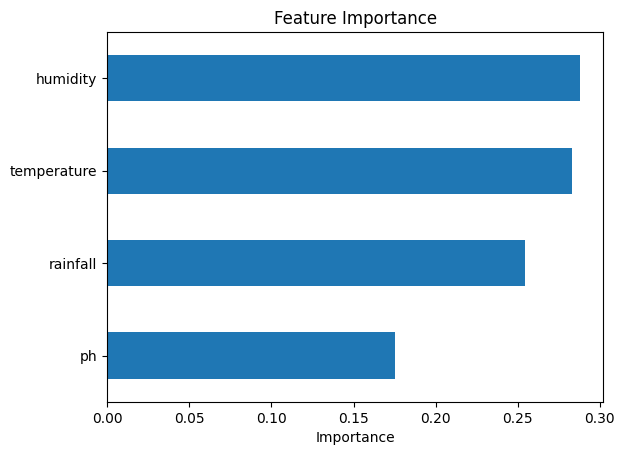

In [ ]:
import matplotlib.pyplot as plt
# Combine feature names correctly
features = soil_features + weather_features

# Check length (debug)
print("Features:", len(features))
print("Importance:", len(baseline.feature_importances_))

# Create feature importance series
feat_imp = pd.Series(baseline.feature_importances_, index=features)

# Plot
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

MULTI MODEL DNN MODEL

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate, Dropout
# Soil branch
soil_input = Input(shape=(1,))
x1 = Dense(64, activation='relu')(soil_input)
x1 = Dense(128, activation='relu')(x1)

# Weather branch
weather_input = Input(shape=(3,))
x2 = Dense(64, activation='relu')(weather_input)
x2 = Dense(128, activation='relu')(x2)

# Fusion layer (multimodal)
combined = Concatenate()([x1, x2])

# Fully connected layers
z = Dense(256, activation='relu')(combined)
z = Dropout(0.3)(z)

z = Dense(128, activation='relu')(z)
z = Dropout(0.3)(z)

z = Dense(64, activation='relu')(z)

# Output layer (N, P, K)
output = Dense(3, activation='linear')(z)

# Final model
model = Model(inputs=[soil_input, weather_input], outputs=output)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │        256 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      8,320 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │      8,320 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 3)         │        195 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 124,163 (485.01 KB)

 Trainable params: 124,163 (485.01 KB)

 Non-trainable params: 0 (0.00 B)

**COMPILATION**

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

**TRAINING MODEL**

In [ ]:
history = model.fit(
    [X_soil_train, X_weather_train],
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 2434.1396 - mae: 35.7233 - val_loss: 1816.7656 - val_mae: 31.6617 - learning_rate: 0.0010
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1723.0870 - mae: 30.8342 - val_loss: 1694.1035 - val_mae: 30.1390 - learning_rate: 0.0010
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1594.1636 - mae: 29.7550 - val_loss: 1516.9012 - val_mae: 28.8222 - learning_rate: 0.0010
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1382.8988 - mae: 27.7574 - val_loss: 1361.8525 - val_mae: 26.0745 - learning_rate: 0.0010
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1117.2197 - mae: 24.4622 - val_loss: 984.9044 - val_mae: 23.4530 - learning_rate: 0.0010
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 909.1534 - mae: 21.6940 - val_loss: 855.1722 - val_mae: 20.7871 - learning_rate: 0.0010
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 863.0902 - mae: 20.7239 - val_loss: 790.0192 - va

In [ ]:
print("\nFinal Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])


Final Training Loss: 286.669189453125
Final Validation Loss: 393.0533142089844


PREDICTION

In [ ]:
y_pred = model.predict([X_soil_test, X_weather_test])

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
print("\nSample Predictions vs Actual:")
print("Predicted:", y_pred[:5])
print("Actual:", y_test.values[:5])


Sample Predictions vs Actual:
Predicted: [[ 99.98704   18.30648   50.418545]
 [ 94.40272   18.151224  46.116863]
 [ 49.2024    50.30744   46.897945]
 [ 43.899757  42.80387   38.912624]
 [ 19.690094 129.70941  195.47905 ]]
Actual: [[101  17  47]
 [ 98   8  51]
 [ 59  62  49]
 [ 44  60  55]
 [ 30 137 200]]


**EVALUATON**

In [ ]:
from sklearn.metrics import  mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)

MSE: 223.9561767578125
MAE: 10.304108619689941
RMSE: 14.965165443716701


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.8392451405525208


In [ ]:
print("\nModel Comparison:")
print("Random Forest MSE:", baseline_mse)
print("DNN MSE:", mse)


Model Comparison:
Random Forest MSE: 200.879891590909
DNN MSE: 223.9561767578125


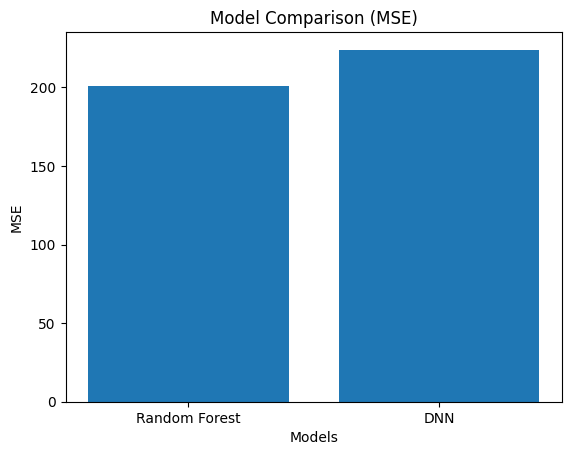

In [ ]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'DNN']
mse_values = [baseline_mse, mse]

plt.figure()
plt.bar(models, mse_values)
plt.title("Model Comparison (MSE)")
plt.xlabel("Models")
plt.ylabel("MSE")
plt.show()

**DEFICIENCY CLASSIFICATION FUNCTION**

In [ ]:
# Thresholds chosen for demonstration; can be replaced with real agricultural standards
def classify_deficiency(x):
    if x < 50:
        return 0   # Low
    elif x < 100:
        return 1   # Medium
    else:
        return 2   # High

In [ ]:
# Convert actual values
y_test_class = np.vectorize(classify_deficiency)(y_test.values)

# Convert predicted values
y_pred_class = np.vectorize(classify_deficiency)(y_pred)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_class = accuracy_score(
    y_test_class.flatten(),
    y_pred_class.flatten()
)

print("\nClassification Accuracy:", accuracy_class * 100, "%")


Classification Accuracy: 82.5 %


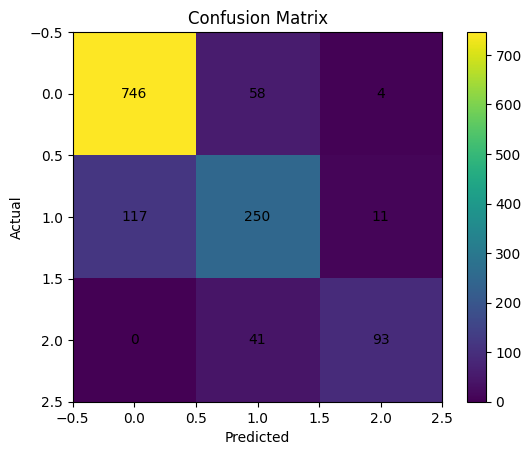

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_class.flatten(),
    y_pred_class.flatten()
)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.show()

**LOSS GRAPH**

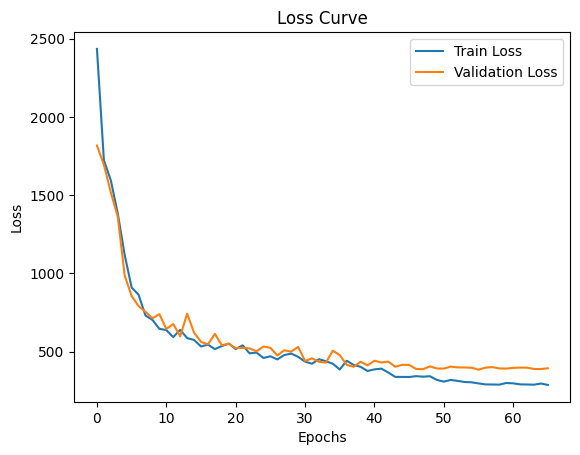

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

Error Analysis

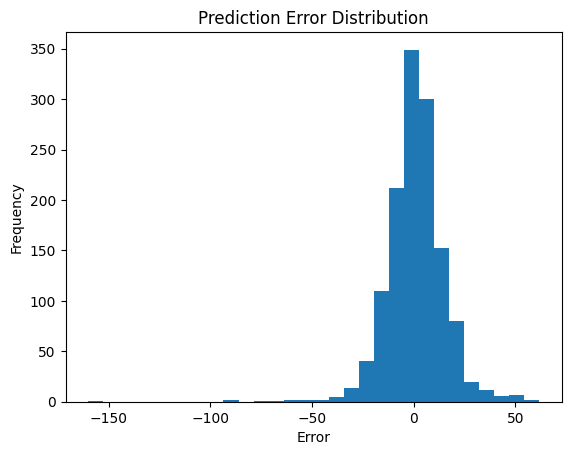

In [ ]:
error = y_test.values - y_pred

plt.figure()
plt.hist(error.flatten(), bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print("Predicted N, P, K:", y_pred)

Predicted N, P, K: [[ 99.98704   18.30648   50.418545]
 [ 94.40272   18.151224  46.116863]
 [ 49.2024    50.30744   46.897945]
 ...
 [127.477486  42.555016  26.210728]
 [107.41341   43.204704  25.277388]
 [ 18.240648  63.31939   18.573378]]


In [ ]:
model.save("soil_nutrient_model.keras")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
def predict_nutrients(ph, temp, humidity, rainfall):
    soil = scaler_soil.transform([[ph]])
    weather = scaler_weather.transform([[temp, humidity, rainfall]])

    pred = model.predict([soil, weather])
    return pred

In [ ]:
result = predict_nutrients(6.5, 25, 70, 100)
print("Predicted NPK values:", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted NPK values: [[92.456604 42.618515 20.939665]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
